In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy.external as sce
import anndata
import harmonypy as hm
from scipy.sparse import csr_matrix #für die sparse matrix
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
from scipy import stats
random_state=10

Matplotlib created a temporary cache directory at /tmp/matplotlib-djlwpf5j because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.4 scipy==1.11.3 pandas==2.2.3 scikit-learn==1.3.1 statsmodels==0.14.0 igraph==0.11.6 pynndescent==0.5.13


In [3]:
adata=sc.read_h5ad('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/global_v8/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_Processed_v8.h5ad')
#OLD:/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_V3.h5ad
#/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_processed_with_new_pcmv_scores_counts_thresholds_v5.h5ad

In [4]:
adata

AnnData object with n_obs × n_vars = 211317 × 8077
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'pCMV_infected_score', 'cell_states', 'leiden_annotated', 'Subgroups', 'Groups', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'Conditions', 'pCMV_infection_threshold2', 'n_genes_pCMV', 'PCMV_infection', 'Condition_subsets'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 

In [5]:
# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================


In [6]:
adata.obs['cell_states'].unique()

['vCM1', 'vCM2_ISG', 'Unassigned', 'Hypoxia_vCM', 'vCM3', ..., 'CD8T_cytox_2_sus', 'NK_CD16hi_sus', 'innate_lymphoid_cells_sus', 'unclassified_sus', 'B_cells_sus']
Length: 75
Categories (78, object): ['Angiogenic_EC', 'Hypoxia_EC', 'Arterial_EC', 'B_cells_sus', ..., 'Hypoxia_vFB', 'vFB8', 'vFB_ISG', 'Prolif_vFB']

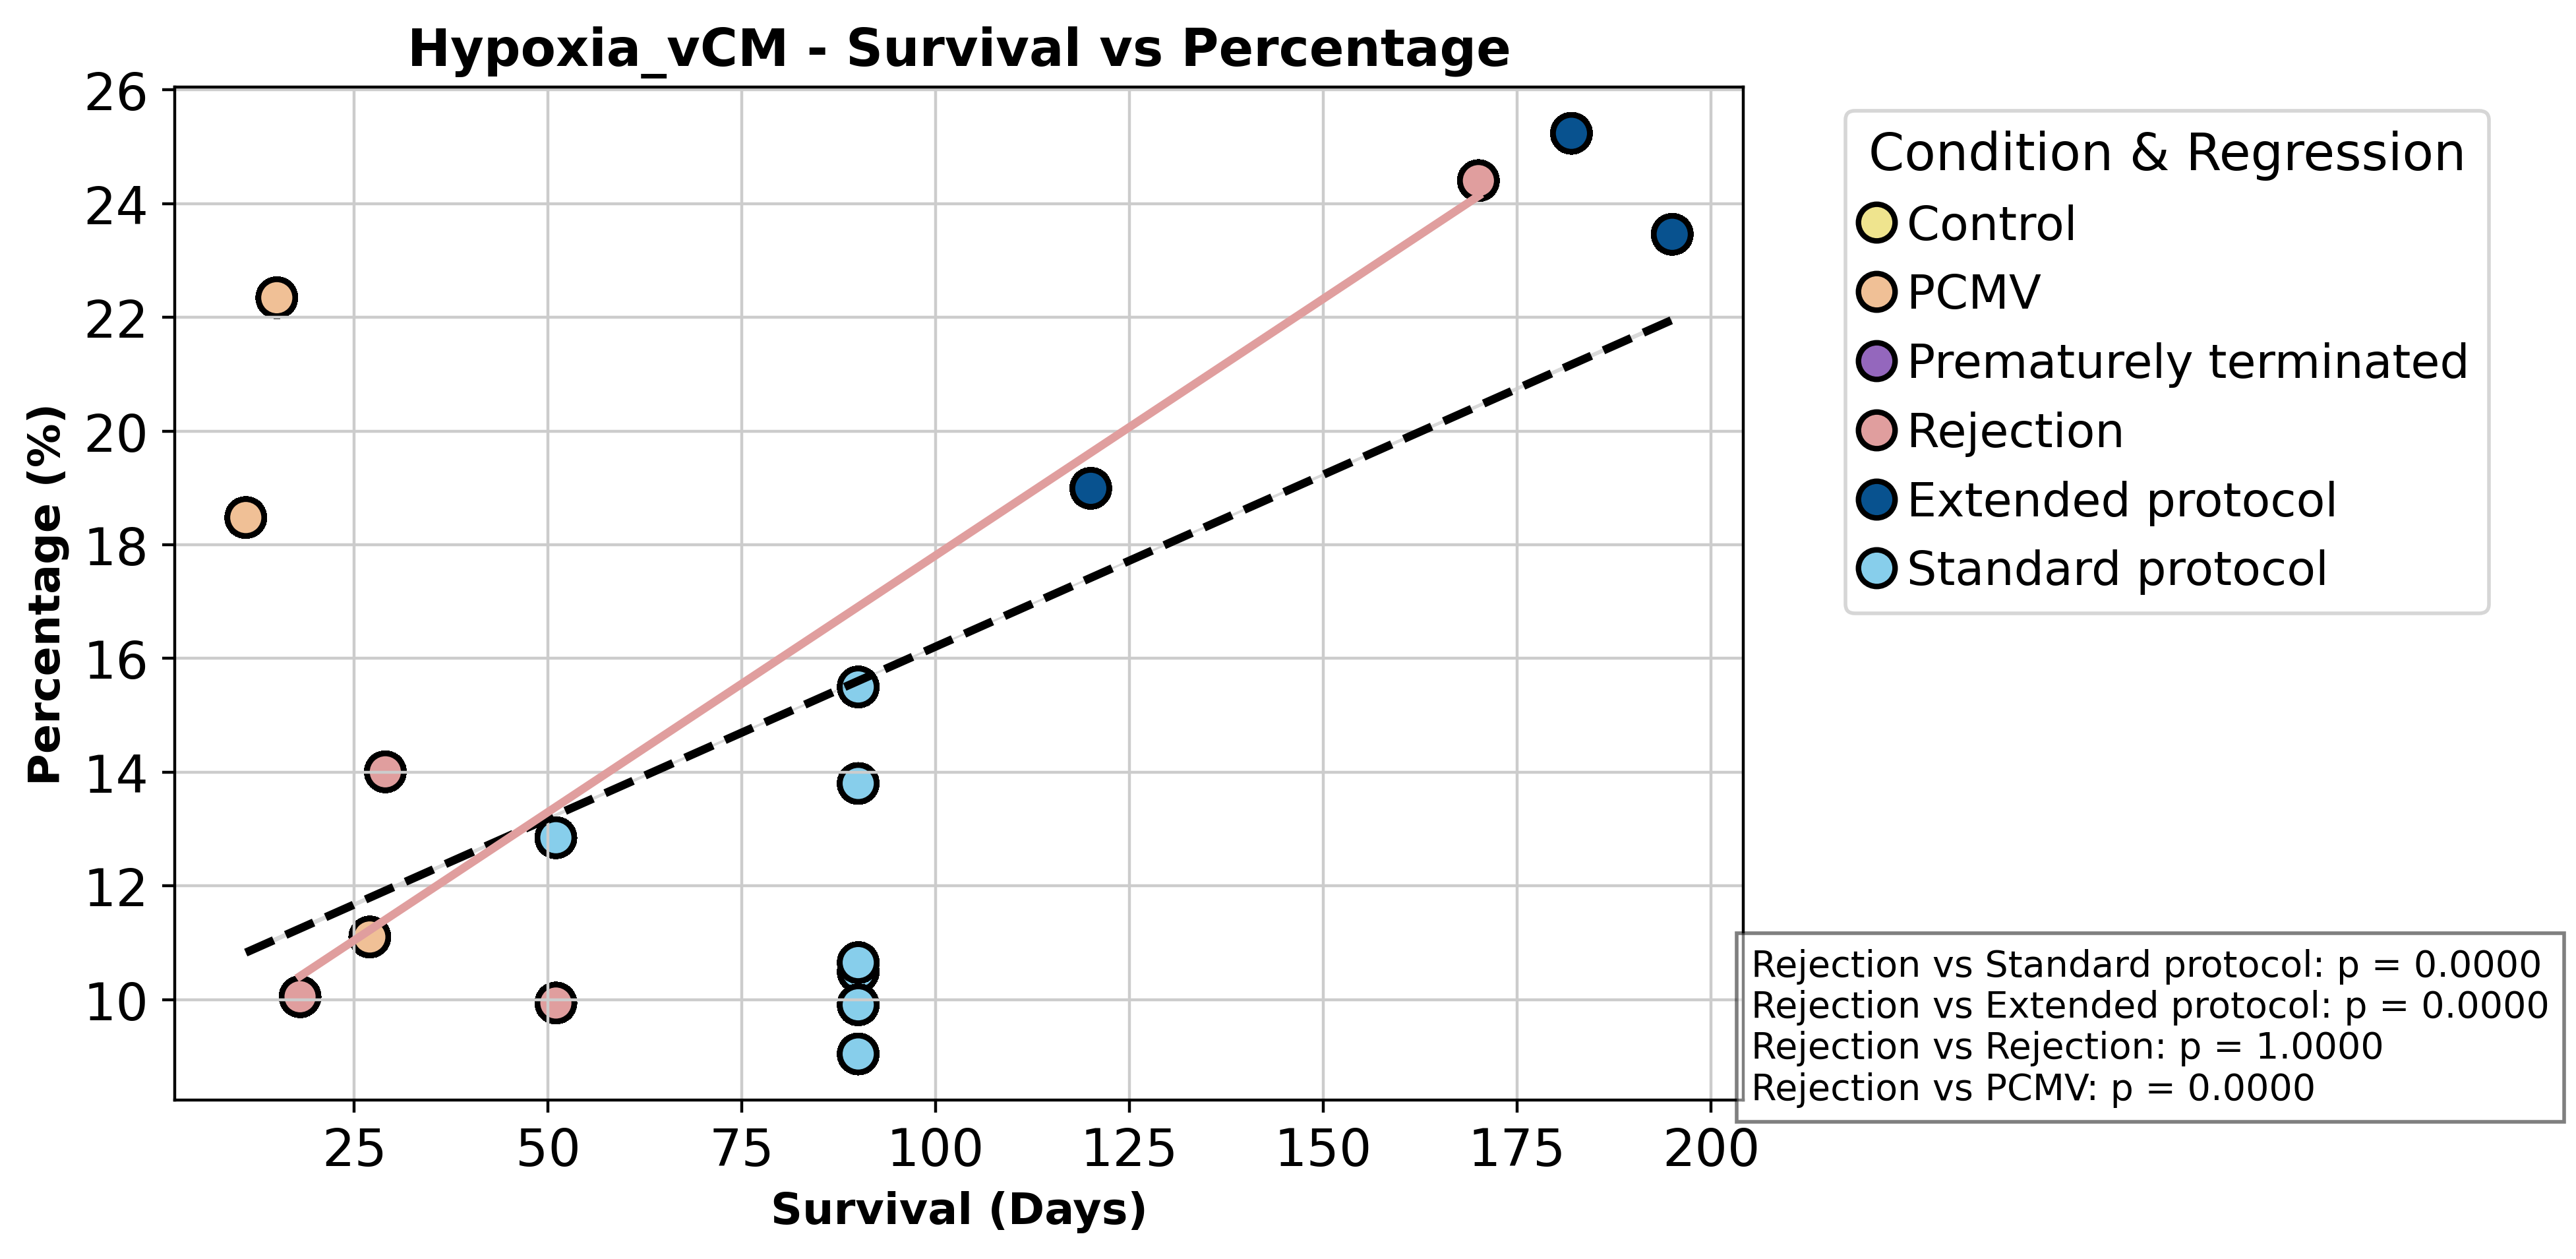

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_survival_vs_cellstate(
    adata_obs,
    cell_state='Hypoxia_vCM',
    groups_col="Condition_subsets",
    color_palette={
        'Control': '#EFE48E',
        'Standard protocol': 'skyblue',
        'Extended protocol': '#08528f',
        'Prematurely terminated':  '#9467bd',
        'Rejection': '#E09E9E',
        'PCMV':  '#F0C096',
    }
):
    # Sicherstellen, dass Sample_ID vorhanden ist
    if 'Sample_ID' not in adata_obs.columns:
        raise ValueError("'Sample_ID' muss in adata.obs.columns vorhanden sein")
    
    # Daten mit expliziter Sample_ID-Spalte erstellen
    required_columns = ['Sample_ID', 'Survival', groups_col, 'cell_states']
    plot_data = adata_obs[required_columns].copy()
    
    # Zelltyp-Prozent pro Sample berechnen
    plot_data['cell_state_percent'] = plot_data.groupby('Sample_ID')['cell_states'].transform(
        lambda x: (x == cell_state).mean() * 100
    )
    
    # Gruppen definieren
    groups = ['Standard protocol','Extended protocol', 'Rejection', 'PCMV' ]
    plot_data = plot_data[plot_data[groups_col].isin(groups)]
    
    # Plot erstellen
    plt.figure(figsize=(10, 5), dpi=200)
    ax = sns.scatterplot(
        data=plot_data,
        x='Survival',
        y='cell_state_percent',
        hue=groups_col,
        palette=color_palette,
        s=100,
        edgecolor='black',
        linewidth=1.5
    )
    
    # Regression für alle Daten (gestrichelte schwarze Linie)
    sns.regplot(
        data=plot_data,
        x='Survival',
        y='cell_state_percent',
        scatter=False,
        ax=ax,
        color='black',
        line_kws={'linestyle':'--', 'label':'Regression (alle)'}
    )

    # Regression für 'Rejection' (rote Linie)
    rejection_data = plot_data[plot_data[groups_col] == 'Rejection']
    if not rejection_data.empty:
        sns.regplot(
            data=rejection_data,
            x='Survival',
            y='cell_state_percent',
            scatter=False,
            ax=ax,
            color=color_palette['Rejection'],
            line_kws={'label':'Regression (Rejection)'}
        )

    # Regression für 'Per protocol' (blaue Linie)
    per_protocol_data = plot_data[plot_data[groups_col] == 'Per protocol']
    if not per_protocol_data.empty:
        sns.regplot(
            data=per_protocol_data,
            x='Survival',
            y='cell_state_percent',
            scatter=False,
            ax=ax,
            color=color_palette['Per protocol'],
            line_kws={'label':'Regression (Per protocol)'}
        )

    # Statistische Vergleiche: Rejection vs. andere Gruppen
    comparisons = []
    for group in groups:
        group_data = plot_data[plot_data[groups_col] == group]
        if not group_data.empty and not rejection_data.empty:
            _, p_value = mannwhitneyu(
                rejection_data['cell_state_percent'],
                group_data['cell_state_percent'],
                alternative='two-sided'
            )
            comparisons.append(f"Rejection vs {group}: p = {p_value:.4f}")

    # Plot-Anpassungen
    plt.title(f"{cell_state} - Survival vs Percentage", fontsize=14, fontweight='bold')
    plt.xlabel('Survival (Days)', fontsize=12, fontweight='bold')
    plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')

    # Legende anpassen (Conditions + Regressionen)
    handles, labels = ax.get_legend_handles_labels()
    # Doppelte Labels entfernen (z.B. für Regressionen)
    from collections import OrderedDict
    label_dict = OrderedDict(zip(labels, handles))
    ax.legend(label_dict.values(), label_dict.keys(), title="Condition & Regression", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Optional: Signifikanz-Text ins Plot einfügen
    if comparisons:
         comparison_text = "\n".join(comparisons)
         plt.text(
             1.005, 0.15, 
             comparison_text,
             transform=ax.transAxes,
             ha='left', 
             va='top',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.5)
         )

    plt.tight_layout()
    plt.show()

# Beispielaufruf
plot_survival_vs_cellstate(
    adata_obs=adata.obs,
    cell_state='Hypoxia_vCM'
)




# Subclustering Cell Types 

In [7]:
adata.obs['cell_type'].unique()

['CM', 'Fibroblasts', 'Vascular EC', 'Endocardial/lymphatic EC', 'Myeloids (baboon)', ..., 'Neuronal cells', 'Lymphoids (baboon)', 'Endothelial cells (baboon)', 'Resident Immune', 'Mast cells (baboon)']
Length: 11
Categories (11, object): ['CM', 'Endocardial/lymphatic EC', 'Endothelial cells (baboon)', 'Fibroblasts', ..., 'Myeloids (baboon)', 'Neuronal cells', 'Resident Immune', 'Vascular EC']

In [8]:
# Subset for Myeloids from baboon with specific conditions
FULL_Subset_adata = adata[
    (adata.obs['cell_type'] == 'Fibroblasts')
].copy()

# Verify the subset
print(f"Subset shape: {FULL_Subset_adata.shape}")
print("Conditions in subset:", FULL_Subset_adata.obs['Condition_subsets'].unique().tolist())


Subset shape: (18120, 8077)
Conditions in subset: ['Standard protocol', 'Rejection', 'Extended protocol', 'PCMV', 'Prematurely terminated', 'Control']


In [9]:
FULL_Subset_adata

AnnData object with n_obs × n_vars = 18120 × 8077
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'pCMV_infected_score', 'cell_states', 'leiden_annotated', 'Subgroups', 'Groups', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'Conditions', 'pCMV_infection_threshold2', 'n_genes_pCMV', 'PCMV_infection', 'Condition_subsets'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', '

In [10]:
adata = FULL_Subset_adata

In [11]:
unique_cell_states = adata.obs['cell_states'].unique()
print(unique_cell_states)


['Unassigned', 'vFB4', 'vFB8', 'Myo_vFB', 'Prolif_vFB', ..., 'Hypoxia_vFB', 'vFB3', 'vFB6', 'vFB5', 'vFB_ISG']
Length: 11
Categories (11, object): ['Unassigned', 'Homeostatic_vFB', 'Myo_vFB', 'vFB3', ..., 'Hypoxia_vFB', 'vFB8', 'vFB_ISG', 'Prolif_vFB']


# With regression lines

Plot saved to /data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/IRIS_plots/Resuls_FB_states/survival_vs_vFB6_SUBSET_FB.pdf


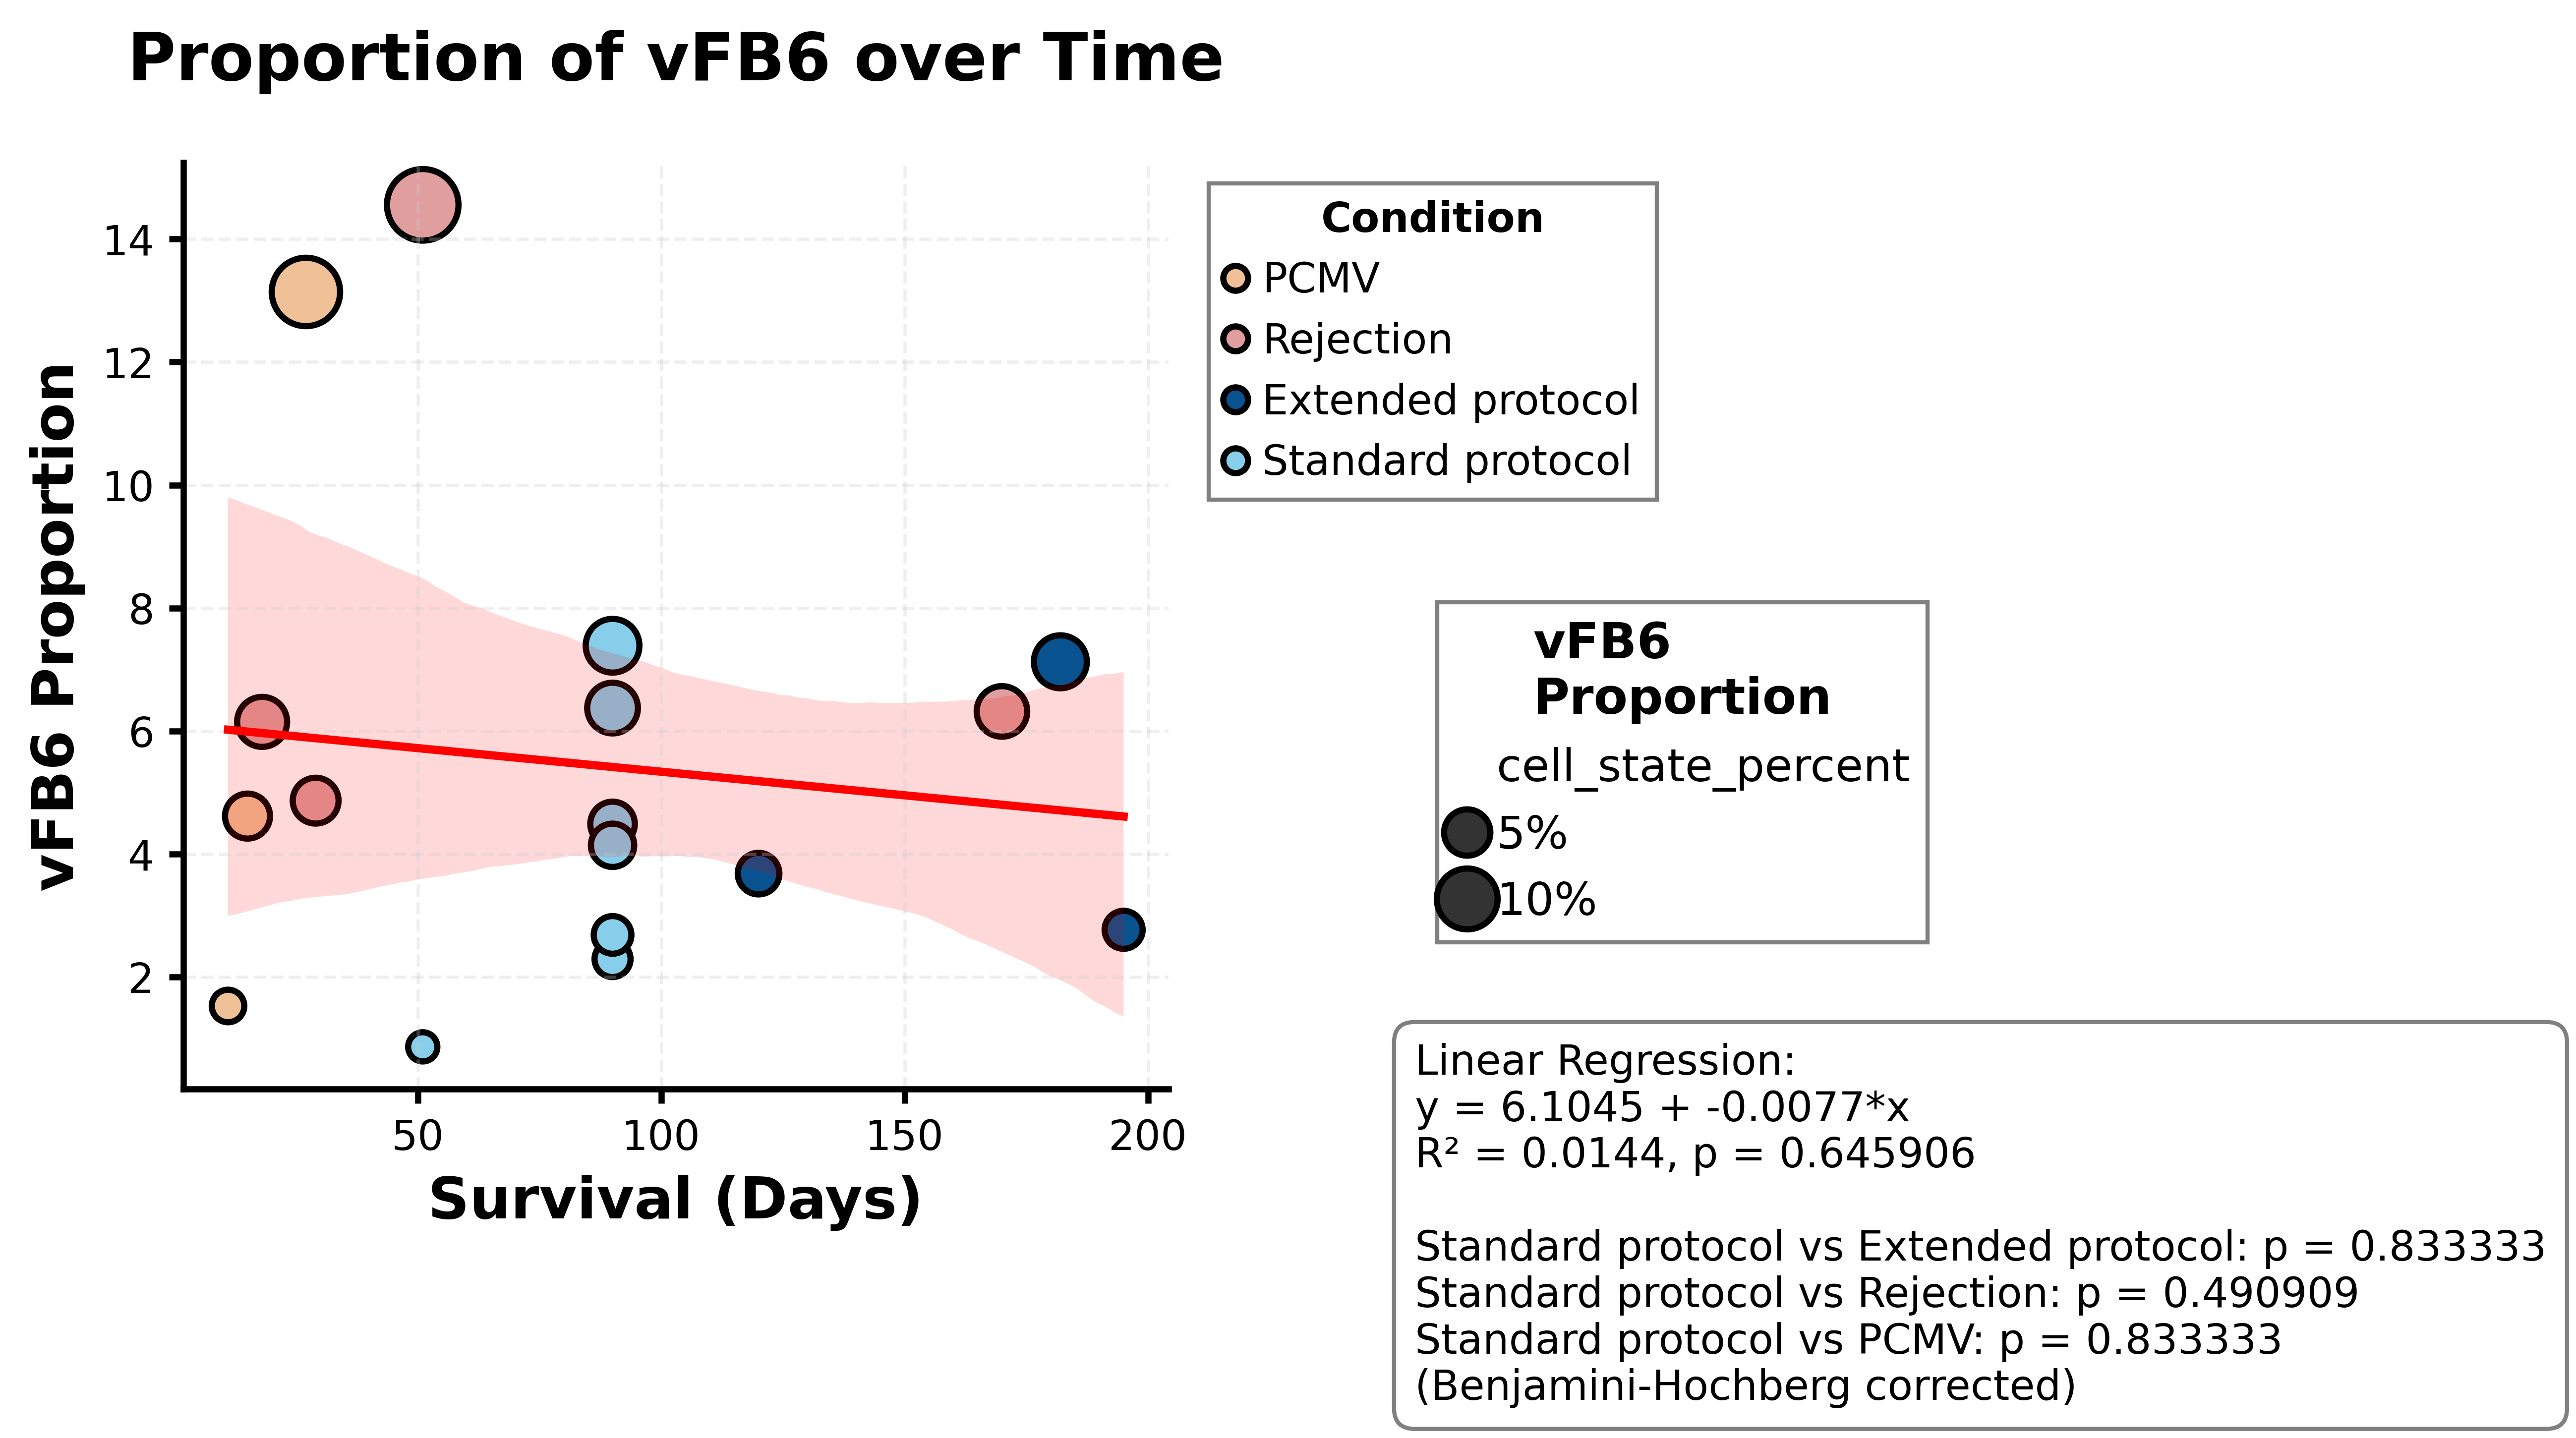

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy import stats  # ADDED: For regression coefficients
from statsmodels.stats.multitest import fdrcorrection
import numpy as np
import os

def plot_survival_vs_cellstate(
    adata_obs,
    cell_state='vFB6',
    groups_col="Condition_subsets",
    color_palette={
        'Control': '#EFE48E',
        'Standard protocol': 'skyblue',
        'Extended protocol': '#08528f',
        'Prematurely terminated':  '#9467bd',
        'Rejection': '#E09E9E',
        'PCMV':  '#F0C096',
    },
    states_to_keep=None,  # Pass a list of states/groups to display
    save=False,
    filename="plot.pdf",
    save_folder="/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/IRIS_plots/Resuls_FB_states"
):
    """
    Plot Survival vs Percentage of cell state with overall regression line and variable dot sizes.
    """

    # Sicherstellen, dass Sample_ID vorhanden ist
    if 'Sample_ID' not in adata_obs.columns:
        raise ValueError("'Sample_ID' muss in adata.obs.columns vorhanden sein")
    
    # Daten mit expliziter Sample_ID-Spalte erstellen
    required_columns = ['Sample_ID', 'Survival', groups_col, 'cell_states']
    plot_data = adata_obs[required_columns].copy()
    
    # Zelltyp-Prozent pro Sample berechnen
    plot_data['cell_state_percent'] = plot_data.groupby('Sample_ID')['cell_states'].transform(
        lambda x: (x == cell_state).mean() * 100
    )
    
    # Gruppen auswählen (Stati filtern)
    available_groups = plot_data[groups_col].unique().tolist()
    if states_to_keep is None:
        groups = available_groups  # Show all states by default
    else:
        groups = [g for g in states_to_keep if g in available_groups]
    plot_data = plot_data[plot_data[groups_col].isin(groups)]
    
    # Unique data per sample für plotting (entfernt Duplikate)
    plot_data_unique = plot_data.drop_duplicates(subset=['Sample_ID']).copy()
    
    # ADDED: Calculate regression coefficients
    slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
        plot_data_unique['Survival'], 
        plot_data_unique['cell_state_percent']
    )
    
    # Plot erstellen
    plt.figure(figsize=(10, 5), dpi=300)  # FIXED: Increased width for better legend spacing
    ax = sns.scatterplot(
        data=plot_data_unique,
        x='Survival',
        y='cell_state_percent',
        hue=groups_col,
        size='cell_state_percent',  # Variable Größe basierend auf Prozentsatz
        sizes=(50, 300),  # Min und Max Größen der Punkte
        palette=color_palette,
        edgecolor='black',
        linewidth=1.5
    )

    # Overall regression line für alle Daten
    sns.regplot(
        data=plot_data_unique,
        x='Survival',
        y='cell_state_percent',
        scatter=False,
        ax=ax,
        color='red',
        line_kws={'linewidth': 2, 'label': 'Overall Regression'}
    )

    # Statistische Vergleiche: Standard protocol vs. andere Gruppen
    standard_protocol_data = plot_data_unique[plot_data_unique[groups_col] == 'Standard protocol']
    p_values = []
    group_names = []
    
    for group in groups:
        group_data = plot_data_unique[plot_data_unique[groups_col] == group]
        if group != "Standard protocol" and not group_data.empty and not standard_protocol_data.empty:
            _, p_value = mannwhitneyu(
                standard_protocol_data['cell_state_percent'],
                group_data['cell_state_percent'],
                alternative='two-sided'
            )
            p_values.append(p_value)
            group_names.append(group)
    
    # Apply Benjamini-Hochberg correction
    if p_values:
        rejected, p_corrected = fdrcorrection(p_values, alpha=0.05, method='indep')
        comparisons = []
        for i, group in enumerate(group_names):
            comparisons.append(f"Standard protocol vs {group}: p = {p_corrected[i]:.6f}")
    else:
        comparisons = []

    # Plot-Anpassungen
    plt.title(f"Proportion of {cell_state.replace('_', ' ')} over Time", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Survival (Days)', fontsize=14, fontweight='bold')
    plt.ylabel(f'{cell_state.replace("_", " ")} Proportion', fontsize=14, fontweight='bold')

    #Better legend handling with proper spacing
    handles, labels = ax.get_legend_handles_labels()
    
    # Separate the color legend (first n handles) from size legend (remaining handles)
    n_groups = len(groups)
    color_handles = []
    color_labels = []
    size_handles = []
    size_labels = []
    
    # Get color handles only for states_to_keep
    for i, label in enumerate(labels):
        if label in groups:
            color_handles.append(handles[i])
            color_labels.append(label)
        elif 'cell_state_percent' in str(label) or label.replace('.0', '').replace('%', '').isdigit():
            # This is a size legend item
            size_handles.append(handles[i])
            # Convert the label to percentage if it's a number
            try:
                val = float(label)
                size_labels.append(f'{val:.0f}%')
            except:
                size_labels.append(label)
    
    # Create color legend - FIXED positioning
    legend1 = ax.legend(color_handles, color_labels, 
                       title='Condition', 
                       title_fontsize=10,
                       fontsize=10,
                       frameon=True,
                       fancybox=False,
                       shadow=False,
                       bbox_to_anchor=(1.02, 1), 
                       loc='upper left')
    
    # Style the color legend
    legend1.get_title().set_fontweight('bold')
    legend1.get_frame().set_facecolor('white')
    legend1.get_frame().set_alpha(1.0)
    legend1.get_frame().set_edgecolor('grey')
    legend1.get_frame().set_linewidth(1.0)
    
    # Add the color legend back to the plot
    ax.add_artist(legend1)
    
    # Create size legend - FIXED positioning (moved down more)
    if size_handles:
        legend2 = ax.legend(size_handles, size_labels,
                           title=f'{cell_state.replace("_", " ")}\nProportion',
                           title_fontsize=12,
                           fontsize=11,
                           frameon=True,
                           fancybox=False,
                           shadow=False,
                           bbox_to_anchor=(1.25, 0.55),  # FIXED: Moved down from 0.65 to 0.55
                           loc='upper left')
        
        # Style the size legend
        legend2.get_title().set_fontweight('bold')
        legend2.get_frame().set_facecolor('white')
        legend2.get_frame().set_alpha(1.0)
        legend2.get_frame().set_edgecolor('grey')
        legend2.get_frame().set_linewidth(1.0)
    else:
        # Fallback: Create size legend by getting unique values from data
        unique_sizes = np.round(plot_data_unique['cell_state_percent'].quantile([0.2, 0.5, 0.8]).values, 0)
        size_handles_manual = []
        size_labels_manual = []
        
        for val in unique_sizes:
            size_handles_manual.append(plt.Line2D([0], [0], marker='o', color='w',
                                                markerfacecolor='grey', 
                                                markersize=8,
                                                markeredgecolor='black', markeredgewidth=1))
            size_labels_manual.append(f'{val:.0f}%')
        
        legend2 = ax.legend(size_handles_manual, size_labels_manual,
                           title=f'{cell_state.replace("_", " ")}\nProportion',
                           title_fontsize=10,
                           fontsize=10,
                           frameon=True,
                           fancybox=False,
                           shadow=False,
                           bbox_to_anchor=(1.25, 0.55),  # FIXED: Moved down from 0.65 to 0.55
                           loc='upper left')
        
        # Style the size legend
        legend2.get_title().set_fontweight('bold')
        legend2.get_frame().set_facecolor('white')
        legend2.get_frame().set_alpha(1.0)
        legend2.get_frame().set_edgecolor('grey')
        legend2.get_frame().set_linewidth(1.0)

    # ADDED: Include regression statistics in the statistics box
    regression_text = f"Linear Regression:\ny = {intercept:.4f} + {slope:.4f}*x\nR² = {r_value**2:.4f}, p = {p_value_reg:.6f}\n\n"
    
    # FIXED: Statistics text positioning (moved down more to avoid overlap)
    if comparisons:
         comparison_text = regression_text + "\n".join(comparisons)
         comparison_text += "\n(Benjamini-Hochberg corrected)"
         plt.text(
             1.25, 0.05,  # FIXED: Moved down from 0.3 to 0.25
             comparison_text,
             transform=ax.transAxes,
             ha='left', 
             va='top',
             fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='grey', alpha=1.0),
             fontweight='normal'
         )
    else:
        # Show regression stats even if no comparisons
        plt.text(
            1.25, 0.25,
            regression_text,
            transform=ax.transAxes,
            ha='left', 
            va='top',
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='grey', alpha=1.0),
            fontweight='normal'
        )

    # Improve overall plot styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=10, width=1.5)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    # Plot speichern, falls verlangt
    if save:
        if not os.path.isdir(save_folder):
            os.makedirs(save_folder)
        # Enforce pdf extension if not already
        if not filename.lower().endswith(".pdf"):
            filename = os.path.splitext(filename)[0] + ".pdf"
        out_path = os.path.join(save_folder, filename)
        plt.savefig(out_path, dpi=300, format='pdf', bbox_inches='tight')
        print(f"Plot saved to {out_path}")

    plt.show()

# Beispielaufruf:
plot_survival_vs_cellstate(
    adata_obs=adata.obs,
    cell_state='vFB6',
    states_to_keep=['Standard protocol','Extended protocol', 'Rejection', 'PCMV'],
    save=True,
    filename="survival_vs_vFB6_SUBSET_FB.pdf"
)


# CSV File with Statistics

In [57]:
def generate_comprehensive_analysis_csv(
    adata_obs,
    cell_state='Hypoxia_vCM',
    groups_col="Condition_subsets",
    states_to_keep=None,
    filename="analysis",
    save_folder="/data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/IRIS_plots/Results_Iris_plots"
):
    """
    Generate comprehensive publication-ready statistical analysis CSV files.
    """
    
    # Sicherstellen, dass Sample_ID vorhanden ist
    if 'Sample_ID' not in adata_obs.columns:
        raise ValueError("'Sample_ID' muss in adata.obs.columns vorhanden sein")
    
    # Daten mit expliziter Sample_ID-Spalte erstellen
    required_columns = ['Sample_ID', 'Survival', groups_col, 'cell_states']
    plot_data = adata_obs[required_columns].copy()
    
    # Zelltyp-Prozent pro Sample berechnen
    plot_data['cell_state_percent'] = plot_data.groupby('Sample_ID')['cell_states'].transform(
        lambda x: (x == cell_state).mean() * 100
    )
    
    # Gruppen auswählen (Stati filtern)
    available_groups = plot_data[groups_col].unique().tolist()
    if states_to_keep is None:
        groups = available_groups
    else:
        groups = [g for g in states_to_keep if g in available_groups]
    plot_data = plot_data[plot_data[groups_col].isin(groups)]
    
    # Unique data per sample
    plot_data_unique = plot_data.drop_duplicates(subset=['Sample_ID']).copy()
    
    # Calculate regression coefficients
    slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
        plot_data_unique['Survival'], 
        plot_data_unique['cell_state_percent']
    )
    
    # Calculate confidence intervals for regression (95% CI)
    n = len(plot_data_unique)
    t_val = stats.t.ppf(0.975, n-2)  # 95% CI
    slope_ci = t_val * std_err
    
    # Statistische Vergleiche: Standard protocol vs. andere Gruppen
    standard_protocol_data = plot_data_unique[plot_data_unique[groups_col] == 'Standard protocol']
    p_values = []
    group_names = []
    effect_sizes = []
    
    for group in groups:
        group_data = plot_data_unique[plot_data_unique[groups_col] == group]
        if group != "Standard protocol" and not group_data.empty and not standard_protocol_data.empty:
            stat, p_value = mannwhitneyu(
                standard_protocol_data['cell_state_percent'],
                group_data['cell_state_percent'],
                alternative='two-sided'
            )
            p_values.append(p_value)
            group_names.append(group)
            
            # Calculate effect size (r = Z/sqrt(N))
            z_score = stats.norm.ppf(p_value/2)  # Convert p to z
            n_total = len(standard_protocol_data) + len(group_data)
            effect_size = abs(z_score) / np.sqrt(n_total)
            effect_sizes.append(effect_size)
    
    # Apply Benjamini-Hochberg correction
    if p_values:
        rejected, p_corrected = fdrcorrection(p_values, alpha=0.05, method='indep')
    else:
        rejected = []
        p_corrected = []

    # =================== CREATE PUBLICATION-READY CSV FILES ===================
    
    # Create save folder if it doesn't exist
    if not os.path.isdir(save_folder):
        os.makedirs(save_folder)
    
    # 1. SAMPLE-LEVEL DATA
    sample_data = plot_data_unique[['Sample_ID', 'Survival', groups_col, 'cell_state_percent']].copy()
    sample_data.columns = ['Sample_ID', 'Survival_Days', 'Condition', f'{cell_state}_Percentage']
    
    # 2. DESCRIPTIVE STATISTICS BY GROUP
    descriptive_stats = []
    for group in groups:
        group_data = plot_data_unique[plot_data_unique[groups_col] == group]
        if not group_data.empty:
            stats_dict = {
                'Condition': group,
                'N': len(group_data),
                'Mean_Survival': group_data['Survival'].mean(),
                'SD_Survival': group_data['Survival'].std(),
                'Median_Survival': group_data['Survival'].median(),
                'IQR_Survival_25': group_data['Survival'].quantile(0.25),
                'IQR_Survival_75': group_data['Survival'].quantile(0.75),
                f'Mean_{cell_state}_Percentage': group_data['cell_state_percent'].mean(),
                f'SD_{cell_state}_Percentage': group_data['cell_state_percent'].std(),
                f'Median_{cell_state}_Percentage': group_data['cell_state_percent'].median(),
                f'IQR_{cell_state}_Percentage_25': group_data['cell_state_percent'].quantile(0.25),
                f'IQR_{cell_state}_Percentage_75': group_data['cell_state_percent'].quantile(0.75),
            }
            descriptive_stats.append(stats_dict)
    
    descriptive_df = pd.DataFrame(descriptive_stats)
    
    # 3. REGRESSION ANALYSIS RESULTS
    regression_results = pd.DataFrame({
        'Analysis': ['Linear_Regression'],
        'Dependent_Variable': [f'{cell_state}_Percentage'],
        'Independent_Variable': ['Survival_Days'],
        'Slope': [slope],
        'Slope_95CI_Lower': [slope - slope_ci],
        'Slope_95CI_Upper': [slope + slope_ci],
        'Intercept': [intercept],
        'R_Squared': [r_value**2],
        'R_Squared_Adjusted': [1 - (1 - r_value**2) * (n - 1) / (n - 2)],
        'Regression_P_Value': [p_value_reg],
        'Standard_Error': [std_err],
        'N_Samples': [n]
    })
    
    # 4. PAIRWISE COMPARISONS
    if p_values:
        pairwise_results = []
        for i, group in enumerate(group_names):
            standard_data = plot_data_unique[plot_data_unique[groups_col] == 'Standard protocol']
            group_data = plot_data_unique[plot_data_unique[groups_col] == group]
            
            pairwise_dict = {
                'Comparison': f'Standard_protocol_vs_{group}',
                'Reference_Group': 'Standard protocol',
                'Comparison_Group': group,
                'Reference_N': len(standard_data),
                'Comparison_N': len(group_data),
                'Reference_Mean': standard_data['cell_state_percent'].mean(),
                'Reference_SD': standard_data['cell_state_percent'].std(),
                'Comparison_Mean': group_data['cell_state_percent'].mean(),
                'Comparison_SD': group_data['cell_state_percent'].std(),
                'Mean_Difference': group_data['cell_state_percent'].mean() - standard_data['cell_state_percent'].mean(),
                'Test_Statistic_Mann_Whitney_U': mannwhitneyu(standard_data['cell_state_percent'], group_data['cell_state_percent'])[0],
                'Raw_P_Value': p_values[i],
                'BH_Corrected_P_Value': p_corrected[i],
                'Significant_BH_Corrected': rejected[i],
                'Effect_Size_r': effect_sizes[i],
                'Statistical_Test': 'Mann-Whitney U'
            }
            pairwise_results.append(pairwise_dict)
        
        pairwise_df = pd.DataFrame(pairwise_results)
    else:
        pairwise_df = pd.DataFrame()
    
    # 5. STUDY METADATA
    metadata = pd.DataFrame({
        'Analysis_Date': [pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')],
        'Cell_State_Analyzed': [cell_state],
        'Groups_Column': [groups_col],
        'Groups_Included': [', '.join(groups)],
        'Total_Samples': [len(plot_data_unique)],
        'Multiple_Testing_Correction': ['Benjamini-Hochberg'],
        'Alpha_Level': [0.05],
        'Regression_Model': ['Ordinary Least Squares'],
        'Statistical_Software': ['Python scipy.stats, statsmodels']
    })
    
    # Save all tables to CSV files
    base_name = filename
    
    # Save individual tables
    sample_data.to_csv(os.path.join(save_folder, f"{base_name}_sample_data.csv"), index=False)
    descriptive_df.to_csv(os.path.join(save_folder, f"{base_name}_descriptive_statistics.csv"), index=False)
    regression_results.to_csv(os.path.join(save_folder, f"{base_name}_regression_analysis.csv"), index=False)
    if not pairwise_df.empty:
        pairwise_df.to_csv(os.path.join(save_folder, f"{base_name}_pairwise_comparisons.csv"), index=False)
    metadata.to_csv(os.path.join(save_folder, f"{base_name}_analysis_metadata.csv"), index=False)
    
    # Create comprehensive summary table
    with open(os.path.join(save_folder, f"{base_name}_complete_analysis_summary.txt"), 'w') as f:
        f.write(f"COMPLETE STATISTICAL ANALYSIS SUMMARY\n")
        f.write(f"=====================================\n\n")
        f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Cell State: {cell_state}\n")
        f.write(f"Total Samples: {len(plot_data_unique)}\n")
        f.write(f"Groups Analyzed: {', '.join(groups)}\n\n")
        
        f.write(f"REGRESSION ANALYSIS:\n")
        f.write(f"Equation: y = {intercept:.6f} + {slope:.6f}*x\n")
        f.write(f"R² = {r_value**2:.6f}\n")
        f.write(f"Slope 95% CI: [{slope - slope_ci:.6f}, {slope + slope_ci:.6f}]\n")
        f.write(f"P-value: {p_value_reg:.6f}\n\n")
        
        if p_values:
            f.write(f"PAIRWISE COMPARISONS (Benjamini-Hochberg corrected):\n")
            for i, group in enumerate(group_names):
                f.write(f"Standard protocol vs {group}: p = {p_corrected[i]:.6f}\n")
    
    print(f"Complete statistical analysis saved to {save_folder}")
    print(f"Files created:")
    print(f"  - {base_name}_sample_data.csv")
    print(f"  - {base_name}_descriptive_statistics.csv") 
    print(f"  - {base_name}_regression_analysis.csv")
    if not pairwise_df.empty:
        print(f"  - {base_name}_pairwise_comparisons.csv")
    print(f"  - {base_name}_analysis_metadata.csv")
    print(f"  - {base_name}_complete_analysis_summary.txt")
    
    return sample_data, descriptive_df, regression_results, pairwise_df, metadata


In [58]:
generate_comprehensive_analysis_csv(
    adata_obs=adata.obs,
    cell_state='Hypoxia_vCM',
    states_to_keep=['Standard protocol','Extended protocol', 'Rejection', 'PCMV'],
    filename="hypoxia_vCM_analysis"
)

Complete statistical analysis saved to /data2/core-med1/fibecker/fibecker/New_data_Xentransplantation/FINAL_whole_object_all_combined/Whole_object analysis/IRIS_plots/Results_Iris_plots
Files created:
  - hypoxia_vCM_analysis_sample_data.csv
  - hypoxia_vCM_analysis_descriptive_statistics.csv
  - hypoxia_vCM_analysis_regression_analysis.csv
  - hypoxia_vCM_analysis_pairwise_comparisons.csv
  - hypoxia_vCM_analysis_analysis_metadata.csv
  - hypoxia_vCM_analysis_complete_analysis_summary.txt


(                         Sample_ID  Survival_Days          Condition  \
 ATCCACCGTATGCTAC___PAV66     PAV66             51  Standard protocol   
 TCGGGCATCTTTCGAT___PAV82     PAV82             90  Standard protocol   
 CATTCTACAGGTCCCA___PAV75     PAV75             90  Standard protocol   
 GTCATTTCAGGACATG___PAV78     PAV78             51          Rejection   
 GGGACTCTCGGTTCAA___PAV72     PAV72            195  Extended protocol   
 AACCCAATCAGCCCAG___PAV85     PAV85            120  Extended protocol   
 CTTCCGAGTTAAACAG___PAV65     PAV65             90  Standard protocol   
 AGCGCTGAGCTGAAGC___PAV76     PAV76             18          Rejection   
 GAACACTTCCCGAACG___PAV71     PAV71            182  Extended protocol   
 CGAGGCTCACCGCTGA___PAV86     PAV86            170          Rejection   
 CACTGTCTCTGGTTGA___PAV68     PAV68             11               PCMV   
 CTCCTCCAGTATAGAC___PAV73     PAV73             15               PCMV   
 TGCATGATCCAGCCTT___PAV79     PAV79             29 

# Without regression lines

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_survival_vs_cellstate(
    adata_obs,
    cell_state='Hypoxia_vCM',
    groups_col="Condition_subsets",
    color_palette={
        'Control': '#EFE48E',
        'Standard protocol': 'skyblue',
        'Extended protocol': '#08528f',
        'Prematurely terminated':  '#C9B8D9',
        'Rejection': '#E09E9E',
        'PCMV':  '#F0C096',
    }
):
    # Sicherstellen, dass Sample_ID vorhanden ist
    if 'Sample_ID' not in adata_obs.columns:
        raise ValueError("'Sample_ID' muss in adata.obs.columns vorhanden sein")
    
    # Daten mit expliziter Sample_ID-Spalte erstellen
    required_columns = ['Sample_ID', 'Survival', groups_col, 'cell_states']
    plot_data = adata_obs[required_columns].copy()
    
    # Zelltyp-Prozent pro Sample berechnen
    plot_data['cell_state_percent'] = plot_data.groupby('Sample_ID')['cell_states'].transform(
        lambda x: (x == cell_state).mean() * 100
    )
    
    # Gruppen definieren
    groups = ['Standard protocol','Extended protocol', 'Rejection', 'PCMV', 
              #'Prematurely terminated', 
              #'Control', 
             ]
    plot_data = plot_data[plot_data[groups_col].isin(groups)]
    
    # Plot erstellen (nur scatterplot, keine Regression!)
    plt.figure(figsize=(8, 4), dpi=300)
    ax = sns.scatterplot(
        data=plot_data,
        x='Survival',
        y='cell_state_percent',
        hue=groups_col,
        palette=color_palette,
        s=100,
        edgecolor='black',
        linewidth=1.5
    )

    # Statistische Vergleiche: Rejection vs. andere Gruppen
    rejection_data = plot_data[plot_data[groups_col] == 'Rejection']
    comparisons = []
    for group in groups:
        group_data = plot_data[plot_data[groups_col] == group]
        if not group_data.empty and not rejection_data.empty:
            _, p_value = mannwhitneyu(
                rejection_data['cell_state_percent'],
                group_data['cell_state_percent'],
                alternative='two-sided'
            )
            comparisons.append(f"Rejection vs {group}: p = {p_value:.4f}")

    # Plot-Anpassungen
    plt.title(f"{cell_state} - Survival vs Percentage", fontsize=12, fontweight='bold')
    plt.xlabel('Survival (Days)', fontsize=12, fontweight='bold')
    plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')

    # Legende anpassen (nur Conditions)
    handles, labels = ax.get_legend_handles_labels()
    from collections import OrderedDict
    label_dict = OrderedDict(zip(labels, handles))
    ax.legend(label_dict.values(), label_dict.keys(), title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Optional: Signifikanz-Text ins Plot einfügen
    if comparisons:
         comparison_text = "\n".join(comparisons)
         plt.text(
             1.1, 0.15, 
             comparison_text,
             transform=ax.transAxes,
             ha='left', 
             va='top',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.5)
         )

    plt.tight_layout()
    plt.show()


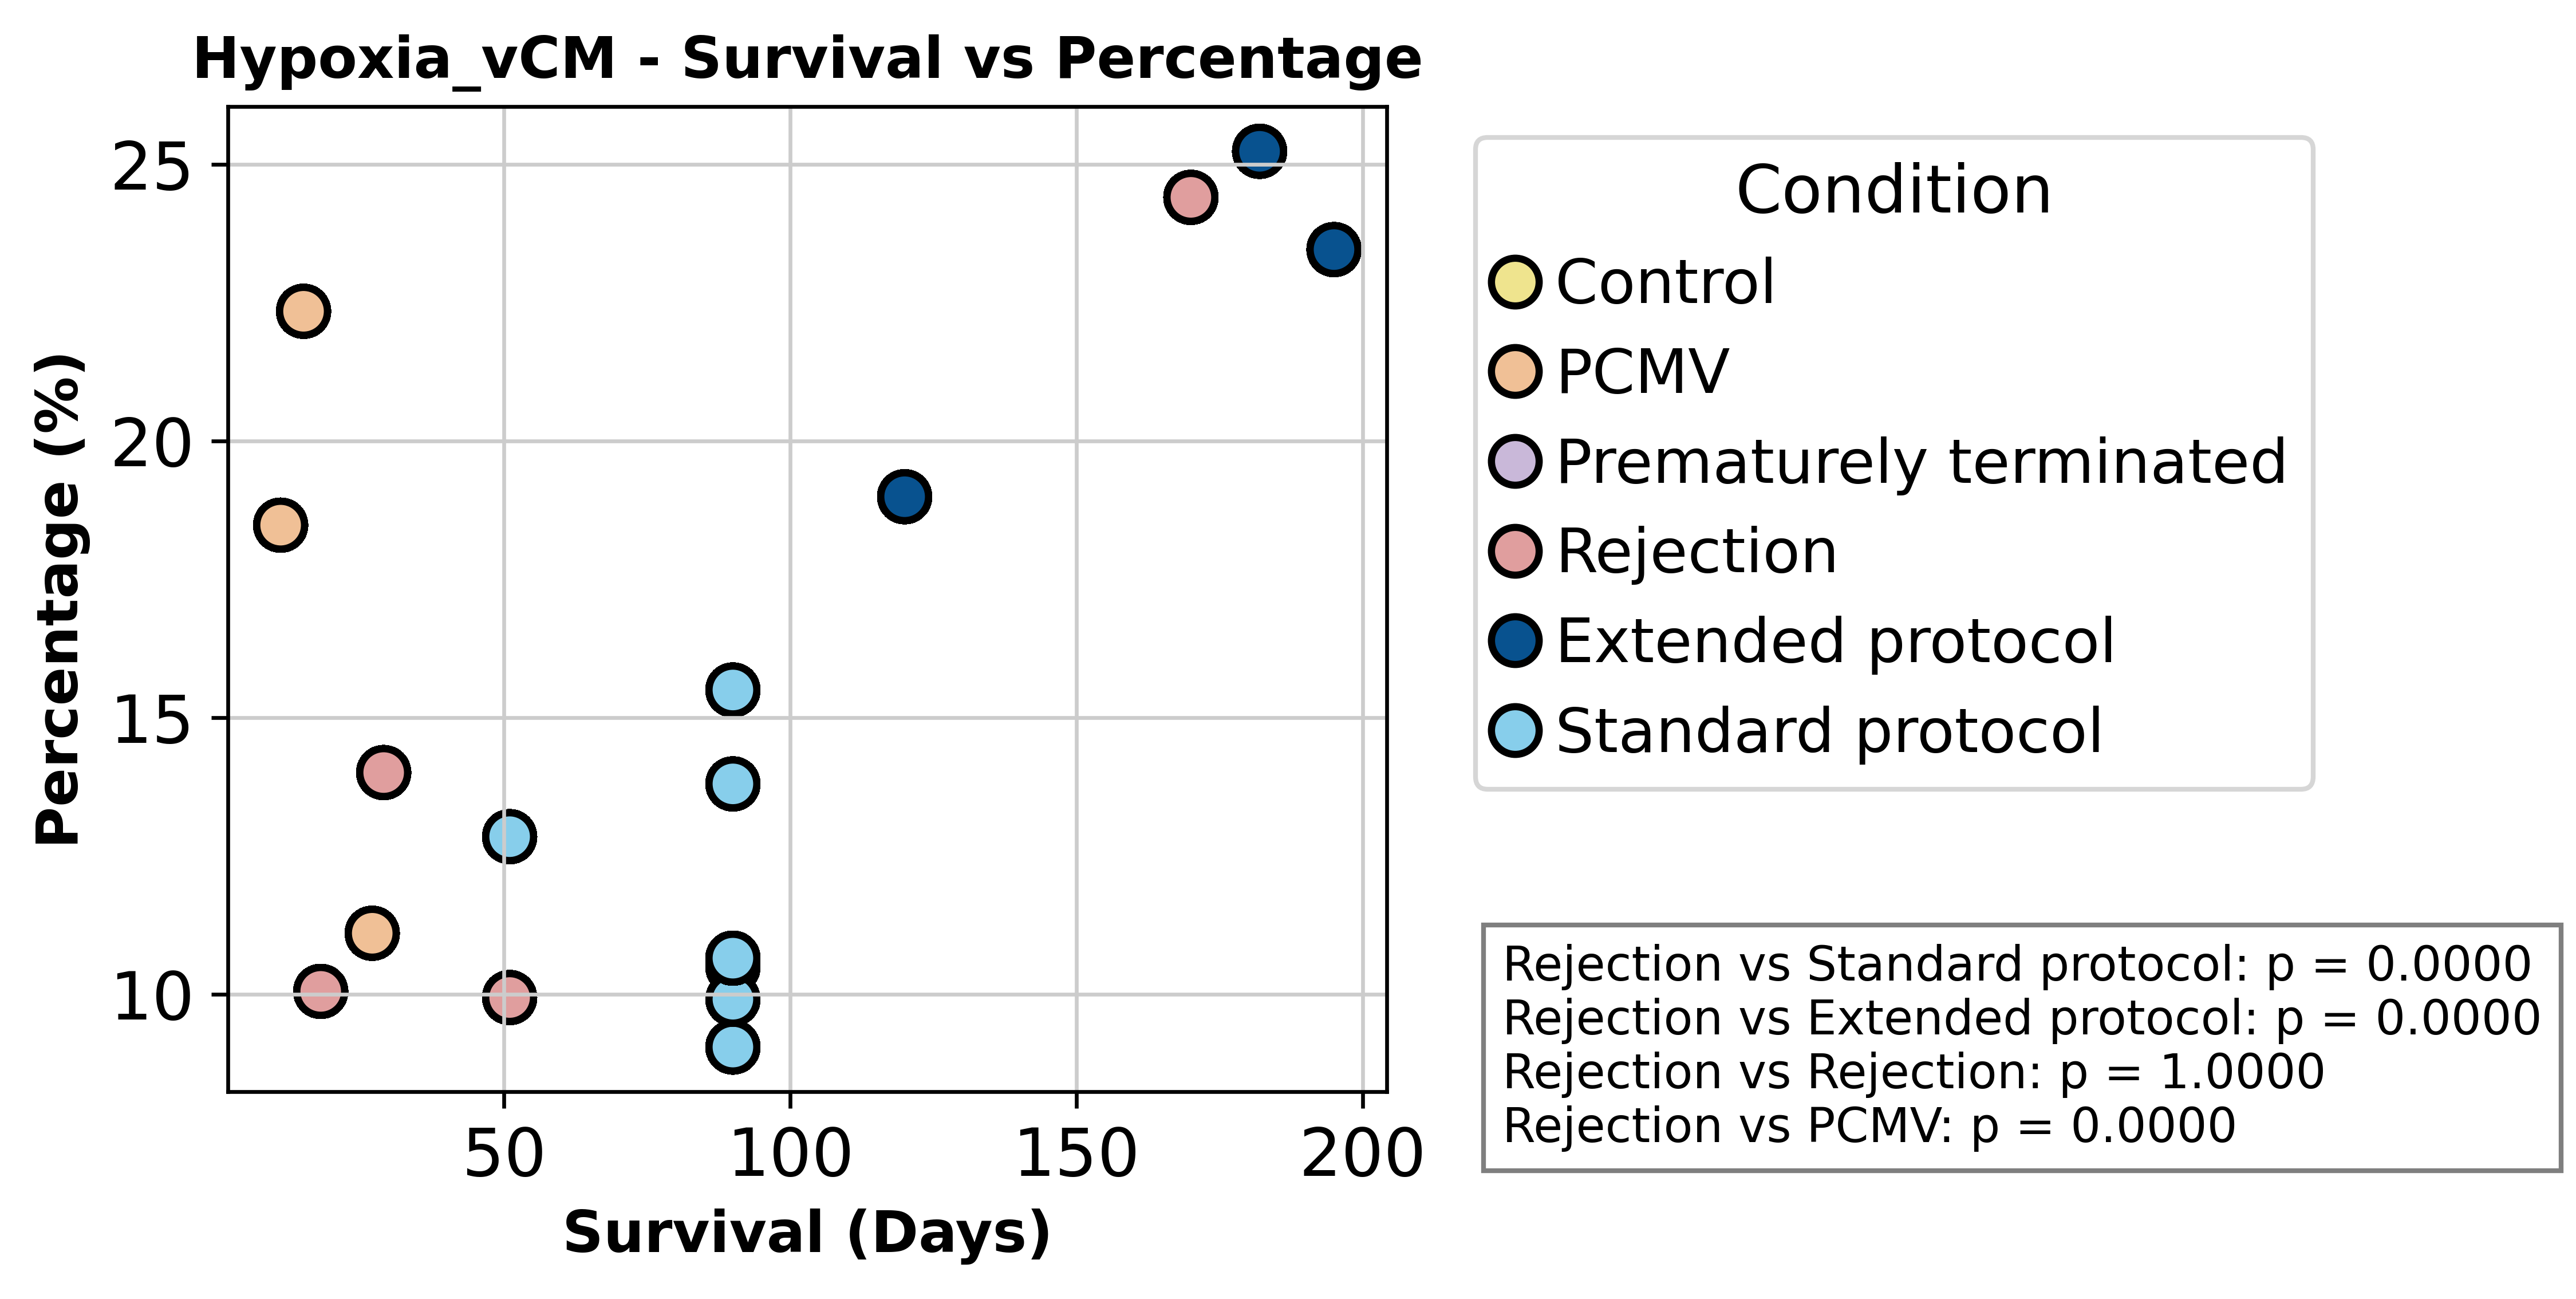

In [35]:
# Beispielaufruf
plot_survival_vs_cellstate(
    adata_obs=adata.obs,
    cell_state='Hypoxia_vCM'
)